In [2]:
import pandas as pd

data = {
    'job_skills': ['python',  'sql', 'java', 'c++', 'html'],
    'skill_count': [30, 25, 20, 15, 10],
    'skill_pay': [100, 90, 80, 70, 60]
}

df = pd.DataFrame(data)

df

,job_skills,skill_count,skill_pay
0,python,30,100
1,sql,25,90
2,java,20,80
3,c++,15,70
4,html,10,60


<Axes: xlabel='skill_count', ylabel='skill_pay'>

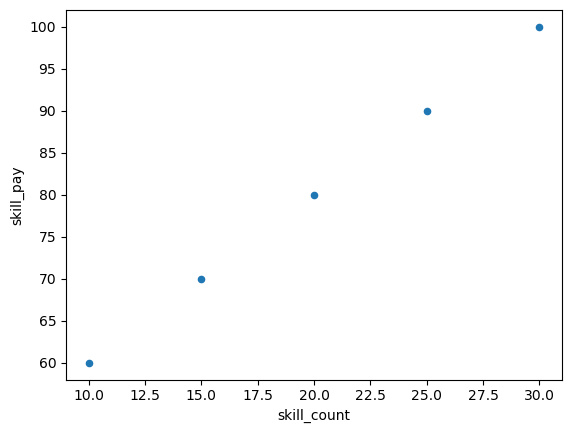

In [3]:
df.plot(kind='scatter', x='skill_count', y='skill_pay')

In [4]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [5]:
df = df[df['job_title_short'] == 'Data Analyst'].copy()

In [6]:
df_exploded = df.explode('job_skills')

skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
)

skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(10)
skill_stats


,skill_count,median_salary
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0


In [9]:
job_title_stats = df.groupby('job_title_short').agg(
    median_salary_year_avg=('salary_year_avg', 'median'),
    job_count=('job_title_short', 'count')
).dropna()

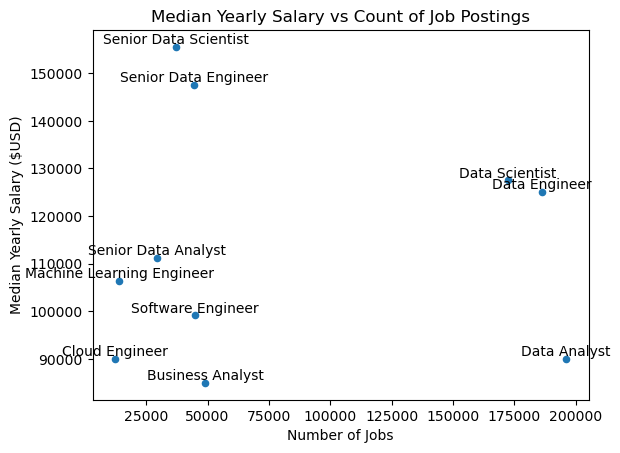

In [10]:
job_title_stats.plot(kind='scatter', x='job_count', y='median_salary_year_avg')
plt.xlabel('Number of Jobs')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Median Yearly Salary vs Count of Job Postings')

for i in range(len(job_title_stats)):
    job_count = job_title_stats['job_count'].iloc[i]
    median_salary = job_title_stats['median_salary_year_avg'].iloc[i]
    job_title = job_title_stats.index[i]
    plt.text(job_count, median_salary, job_title, ha='center', va='bottom')

plt.show()

In [12]:
country_stats = df.groupby('job_country').agg(
    job_count=('job_country', 'count'),
    median_yearly_salary=('salary_year_avg', 'median')
).dropna()

top_countries = country_stats.sort_values(by='job_count', ascending=False).head(7)

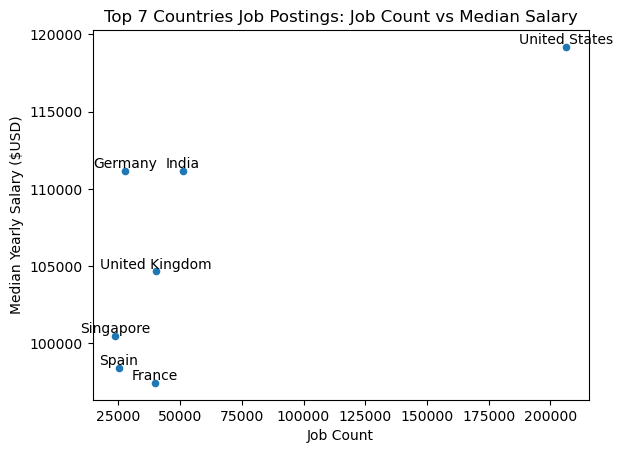

In [13]:
top_countries.plot(kind='scatter', x='job_count', y='median_yearly_salary')
plt.xlabel('Job Count')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Top 7 Countries Job Postings: Job Count vs Median Salary')

for i in range(len(top_countries)):
    job_count = top_countries['job_count'].iloc[i]
    median_salary = top_countries['median_yearly_salary'].iloc[i]
    country = top_countries.index[i]
    plt.text(job_count, median_salary, country, ha='center', va='bottom')

plt.show()

In [ ]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()


# Define specific job titles to include
target_job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

# Filter US jobs for only full-time and part-time roles and specific job titles, then drop rows with missing salary data
us_jobs_df = df[
   (df['job_country'] == 'United States') &
   (df['job_schedule_type'].isin(['Full-time', 'Contractor'])) &
   (df['job_title_short'].isin(target_job_titles))
].dropna(subset=['salary_year_avg']).copy()

# Group by job schedule type and job title, calculate mean yearly salary and job count
stats = us_jobs_df.groupby(['job_schedule_type', 'job_title_short']).agg(
   mean_salary_year_avg=('salary_year_avg', 'mean'),
   job_count=('job_title_short', 'count')
).dropna()

# Reset the index to make plotting easier
stats.reset_index(inplace=True)

# Combine title and type into one value for labels
stats['job_title_type'] = stats['job_title_short'] + ' - ' + stats['job_schedule_type']

# Plot using plt.scatter()
for job_title_type in stats['job_title_type'].unique():
   subset = stats[stats['job_title_type'] == job_title_type]
   plt.scatter(subset['job_count'], subset['mean_salary_year_avg'], label=job_title_type)

plt.xlabel('Number of Jobs')
plt.ylabel('Average Yearly Salary (USD)')
plt.title('Average Yearly Salary vs. Job Count for Top Roles by Schedule Type')
plt.legend()
plt.show()

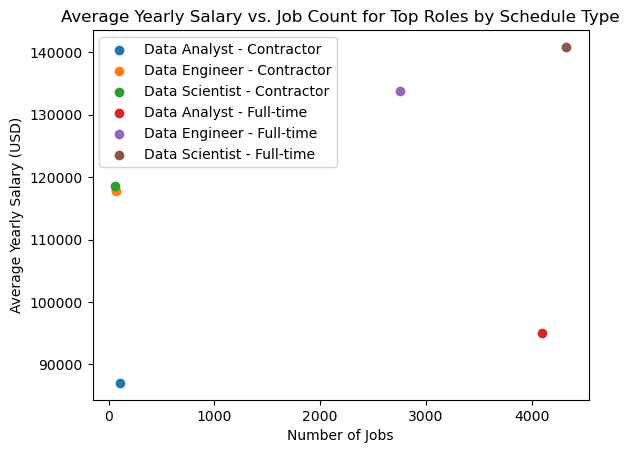

In [18]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Define specific job titles to include
target_job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

# Filter US jobs for only full-time and part-time roles and specific job titles, then drop rows with missing salary data
us_jobs_df = df[
   (df['job_country'] == 'United States') &
   (df['job_schedule_type'].isin(['Full-time', 'Contractor'])) &
   (df['job_title_short'].isin(target_job_titles))
].dropna(subset=['salary_year_avg']).copy()

# Group by job schedule type and job title, calculate mean yearly salary and job count
stats = us_jobs_df.groupby(['job_schedule_type', 'job_title_short']).agg(
   mean_salary_year_avg=('salary_year_avg', 'mean'),
   job_count=('job_title_short', 'count')
).dropna()

# Reset the index to make plotting easier
stats.reset_index(inplace=True)

# Combine title and type into one value for labels
stats['job_title_type'] = stats['job_title_short'] + ' - ' + stats['job_schedule_type']

# Plot using plt.scatter()
for job_title_type in stats['job_title_type'].unique():
   subset = stats[stats['job_title_type'] == job_title_type]
   plt.scatter(subset['job_count'], subset['mean_salary_year_avg'], label=job_title_type)

plt.xlabel('Number of Jobs')
plt.ylabel('Average Yearly Salary (USD)')
plt.title('Average Yearly Salary vs. Job Count for Top Roles by Schedule Type')
plt.legend()
plt.show()

In [19]:
target_job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

us_jobs_df = df[
    (df['job_country'] == 'United States') &
    (df['job_schedule_type'].isin(['Full-time', 'Contractor'])) &
    (df['job_title_short'].isin(target_job_titles))
].dropna(subset=['salary_year_avg']).copy()

stats = us_jobs_df.groupby(['job_schedule_type', 'job_title_short']).agg(
    mean_salary_year_avg = ('salary_year_avg', 'mean'),
    job_count = ('job_title_short', 'count')
).dropna()

stats.reset_index(inplace=True)

In [20]:
stats['job_title_type'] = stats['job_title_short'] + ' - ' + stats['job_schedule_type']

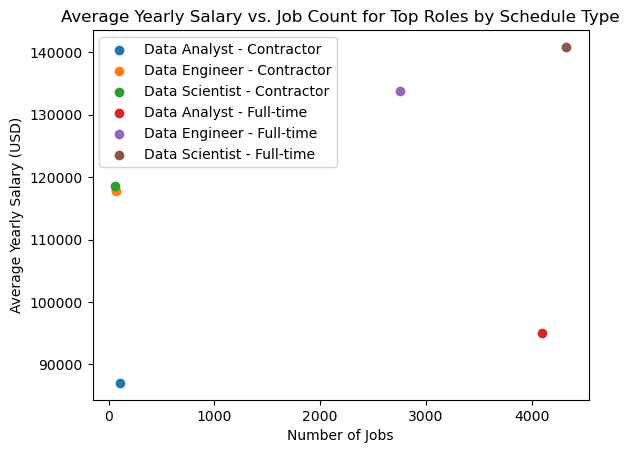

In [21]:
for job_title_type in stats['job_title_type'].unique():
    subset = stats[stats['job_title_type'] == job_title_type]
    plt.scatter(subset['job_count'], subset['mean_salary_year_avg'], label=job_title_type)

plt.xlabel('Number of Jobs')
plt.ylabel('Average Yearly Salary (USD)')
plt.title('Average Yearly Salary vs. Job Count for Top Roles by Schedule Type')
plt.legend()
plt.show()